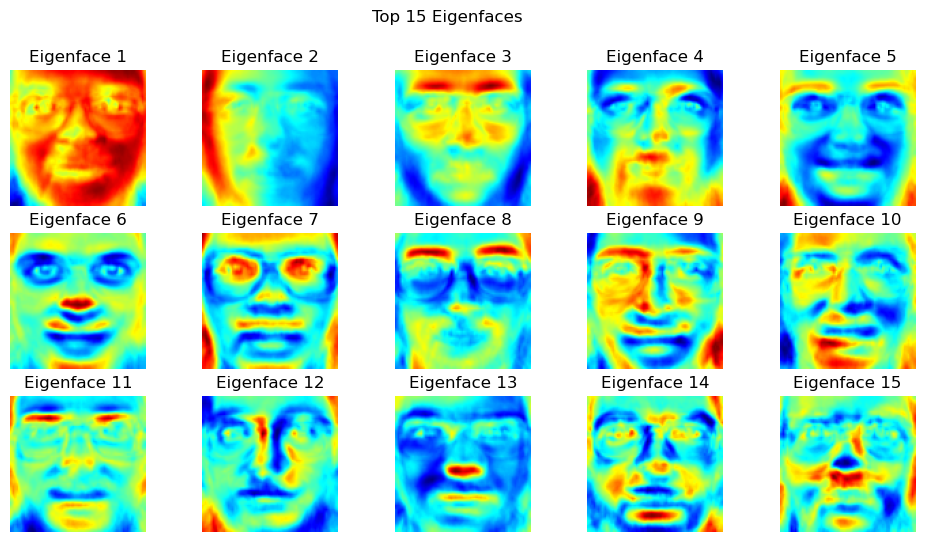

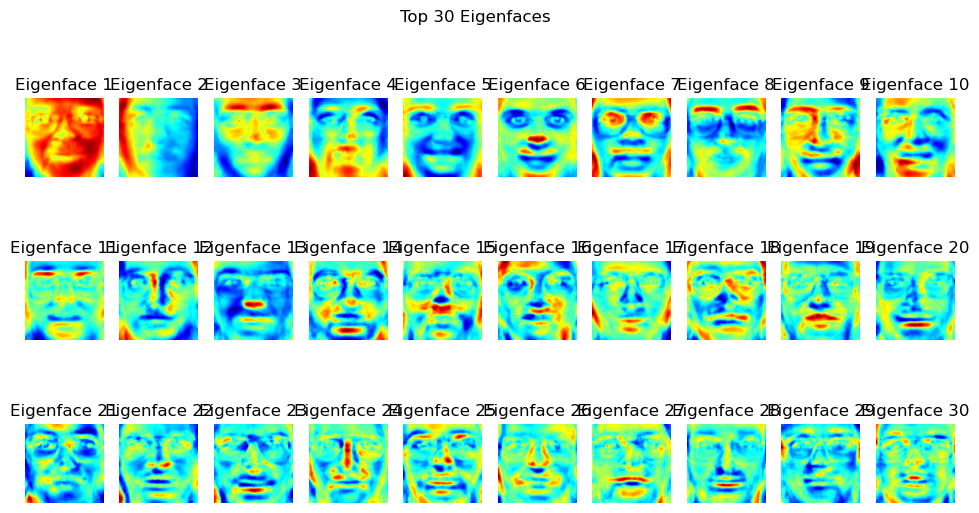

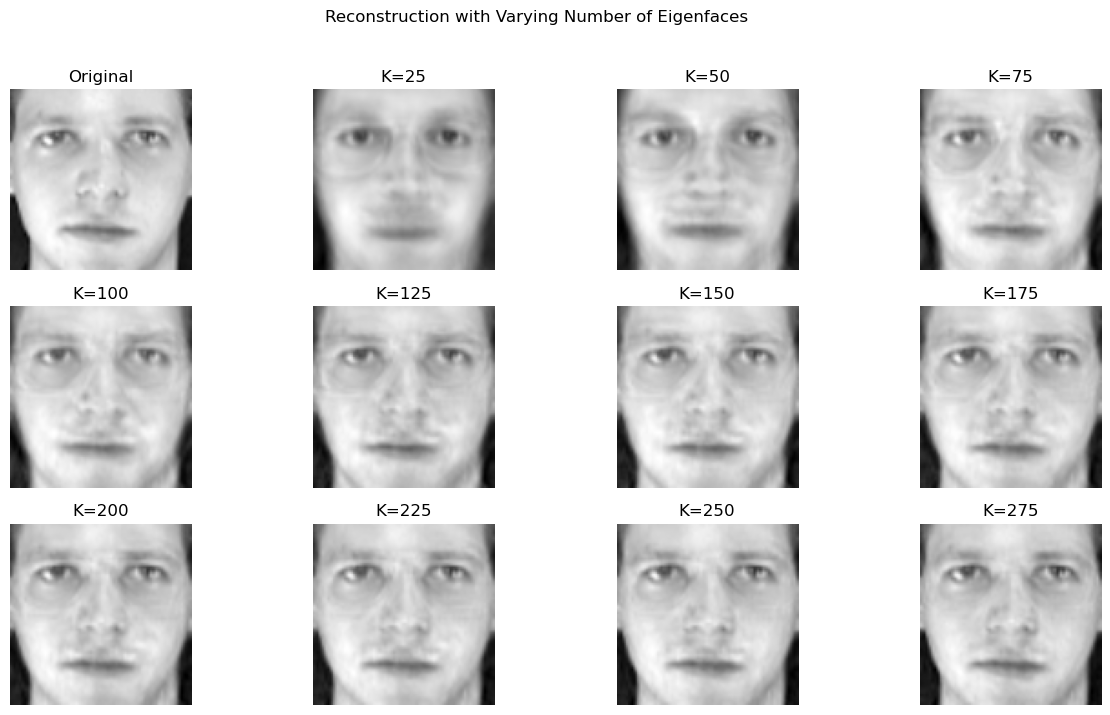

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
from sklearn.datasets import fetch_olivetti_faces
from sklearn.decomposition import PCA

# 1. Load and preprocess the dataset
faces = fetch_olivetti_faces()
images = faces.images  # shape: (400, 64, 64)

# Resize to 100x100 and flatten
resized_images = [cv2.resize(img, (100, 100)) for img in images]
flattened_images = [img.flatten() for img in resized_images]
X = np.array(flattened_images)

# 2. Apply PCA
pca = PCA().fit(X)
eigenfaces = pca.components_

# 3. Visualize top K eigenfaces with colormap
def show_eigenfaces(eigenfaces, num, title):
    plt.figure(figsize=(12, 6))
    for i in range(num):
        face = eigenfaces[i].reshape(100, 100)
        face_uint8 = cv2.normalize(face, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
        face_colormap = cv2.applyColorMap(face_uint8, cv2.COLORMAP_JET)
        plt.subplot(3, num//3, i+1)
        plt.imshow(cv2.cvtColor(face_colormap, cv2.COLOR_BGR2RGB))
        plt.axis('off')
        plt.title(f'Eigenface {i+1}')
    plt.suptitle(title)
    plt.show()

show_eigenfaces(eigenfaces, 15, 'Top 15 Eigenfaces')
show_eigenfaces(eigenfaces, 30, 'Top 30 Eigenfaces')

# 4. Reconstruct an example face using different numbers of eigenfaces
example_face = X[0]
ks = np.arange(25, 300, 25, dtype=int)

plt.figure(figsize=(15, 8))
plt.subplot(3, len(ks)//3 + 1, 1)
plt.imshow(example_face.reshape(100, 100), cmap='gray')
plt.title('Original')
plt.axis('off')

for i, k in enumerate(ks):
    pca_k = PCA(n_components=k)
    X_pca = pca_k.fit_transform(X)
    reconstructed = pca_k.inverse_transform(X_pca[0])
    plt.subplot(3, len(ks)//3 + 1, i+2)
    plt.imshow(reconstructed.reshape(100, 100), cmap='gray')
    plt.title(f'K={k}')
    plt.axis('off')

plt.suptitle('Reconstruction with Varying Number of Eigenfaces')
plt.show()


#explanation: 
#Step 3: PCA identifies the most significant features (eigenfaces) that explain variance in facial images. Visualizing them helps understand what features are most important across the dataset.
#Step 4: Reconstructing a face using different numbers of eigenfaces shows how dimensionality affects image quality. Fewer components lead to blurry reconstructions; more components yield sharper, more accurate faces.